In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


Data Description:


,age,sex,trestbps,chol,fbs,restecg,thalach,exang,cp,oldpeak,slope,ca,thal,target
0,29,1,130,204,0,0,202,0,1,0.0,2,0,2,1
1,29,1,130,204,0,0,202,0,1,0.0,2,0,2,1
2,29,1,130,204,0,0,202,0,1,0.0,2,0,2,1
3,29,1,130,204,0,0,202,0,1,0.0,2,0,2,1
4,34,0,118,210,0,1,192,0,1,0.7,2,0,2,1


Dataset Shape: (1025, 14)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   trestbps  1025 non-null   int64  
 3   chol      1025 non-null   int64  
 4   fbs       1025 non-null   int64  
 5   restecg   1025 non-null   int64  
 6   thalach   1025 non-null   int64  
 7   exang     1025 non-null   int64  
 8   cp        1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

Summary Statistics:


,age,sex,trestbps,chol,fbs,restecg,thalach,exang,cp,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,0.942439,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.029641,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,1.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,2.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,3.000000,6.200000,2.000000,4.000000,3.000000,1.000000


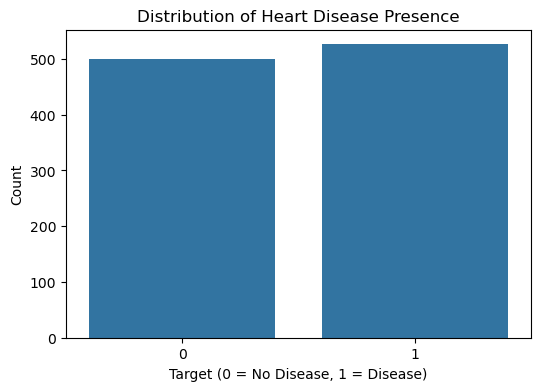

In [5]:
# Load the dataset
df = pd.read_csv('Dataset.csv')

# Data Description
print("\nData Description:")
display(df.head())

# Check the dataset dimensions
print(f"Dataset Shape: {df.shape}")

# View data types and check for missing values
print("\nDataset Info:")
df.info()

# Generate summary statistics for numerical features
print("\nSummary Statistics:")
display(df.describe())

# Visualize the Target Variable distribution (1 = Disease, 0 = No Disease)
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.title('Distribution of Heart Disease Presence')
plt.xlabel('Target (0 = No Disease, 1 = Disease)')
plt.ylabel('Count')
plt.show()

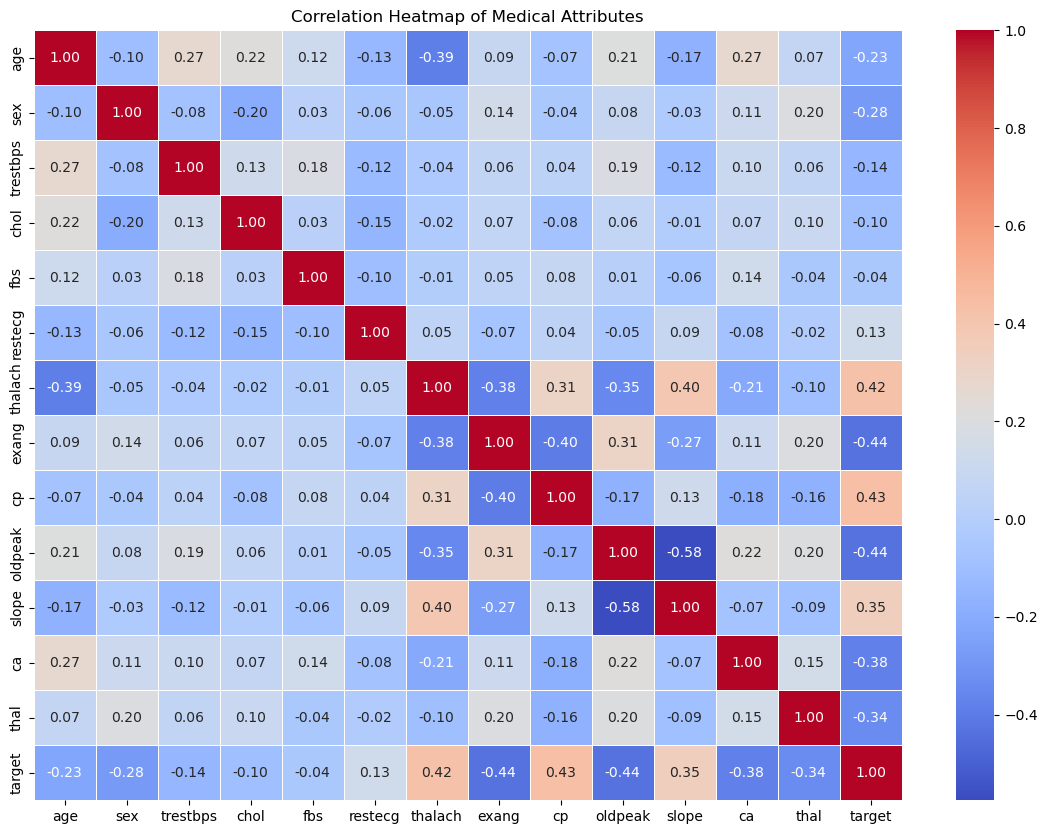

Data Preprocessing Steps

1. Checking for missing values:
0 missing values found.

2. Shape before removing duplicates: (1025, 14)
   Shape after removing duplicates: (302, 14)

3. Categorical variables encoded.

4. Data split into training and testing sets. Training size: 241, Testing size: 61

5. Numerical features scaled.

Preprocessing Complete! The data is now ready for machine learning.


In [6]:
# VISUALIZATION 

# Correlation Heatmap 
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Medical Attributes')
plt.show()

# DATA PREPROCESSING 
print("Data Preprocessing Steps")

# 1. Handling Missing Values
print("\n1. Checking for missing values:")
print(df.isnull().sum().sum(), "missing values found.")

# 2. Removing Duplicates
print(f"\n2. Shape before removing duplicates: {df.shape}")
df = df.drop_duplicates()
print(f"   Shape after removing duplicates: {df.shape}")

# 3. Encoding Categorical Variables
categorical_cols = ['cp', 'restecg', 'slope', 'ca', 'thal']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("\n3. Categorical variables encoded.")

# 4. Data Splitting
from sklearn.model_selection import train_test_split

# Separate features (X) and the target variable (y)
X = df.drop('target', axis=1) 
y = df['target'] 

# Split 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\n4. Data split into training and testing sets. Training size: {X_train.shape[0]}, Testing size: {X_test.shape[0]}")

# 5. Feature Scaling
from sklearn.preprocessing import StandardScaler

# Identify the numerical columns that need scaling
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
scaler = StandardScaler()

# Fit the scaler ONLY on the training data, then transform both train and test data
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])
print("\n5. Numerical features scaled.")
print("\nPreprocessing Complete! The data is now ready for machine learning.")

--- Decision Tree Performance ---
Accuracy:  0.7869
Precision: 0.8214
Recall:    0.7419
F1 Score:  0.7797

--- K-Nearest Neighbors (KNN) Performance ---
Accuracy:  0.8525
Precision: 0.8667
Recall:    0.8387
F1 Score:  0.8525



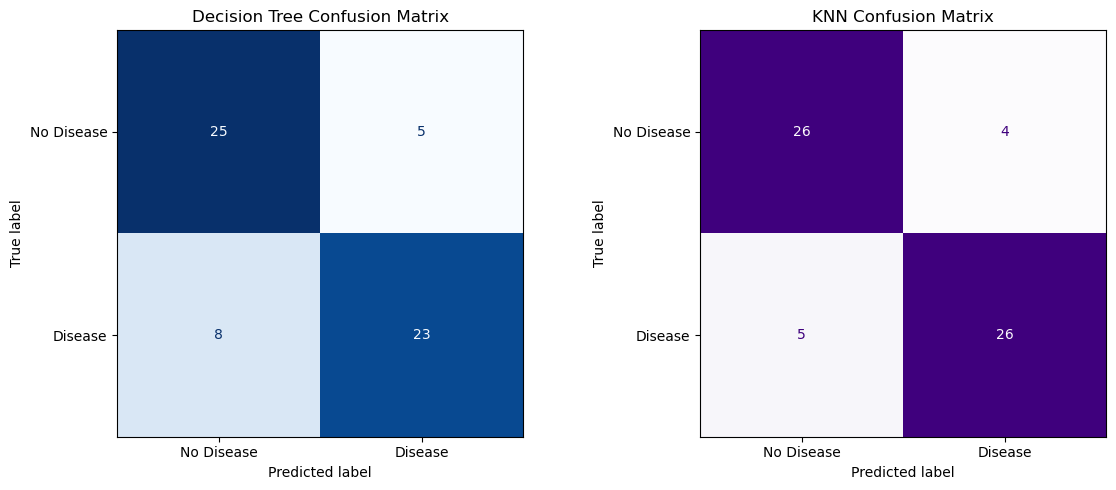

In [7]:
# MODELING & EVALUATION 

# Function to calculate and print evaluation metrics
def evaluate_model(model_name, y_true, y_pred):
    print(f"--- {model_name} Performance ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_true, y_pred):.4f}\n")

# 1. Train and Evaluate Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)
evaluate_model("Decision Tree", y_test, dt_predictions)

# 2. Train and Evaluate K-Nearest Neighbors (KNN)
# Using n_neighbors=5 as a standard starting point
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_predictions = knn_model.predict(X_test)
evaluate_model("K-Nearest Neighbors (KNN)", y_test, knn_predictions)

# 3. Plot Confusion Matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Decision Tree Confusion Matrix
cm_dt = confusion_matrix(y_test, dt_predictions)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['No Disease', 'Disease'])
disp_dt.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Decision Tree Confusion Matrix')

# KNN Confusion Matrix
cm_knn = confusion_matrix(y_test, knn_predictions)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['No Disease', 'Disease'])
disp_knn.plot(ax=axes[1], cmap='Purples', colorbar=False)
axes[1].set_title('KNN Confusion Matrix')

plt.tight_layout()
plt.show()

In [8]:
import joblib

# 1. Save the trained Decision Tree model
joblib.dump(dt_model, 'decision_tree_model.pkl')

# 2. Save the scaler
joblib.dump(scaler, 'scaler.pkl')

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!
